# Análise Exploratória (EDA)

**Objetivo de negócio:** estimar o gasto mensal esperado de cada cliente a partir do seu perfil e comportamento, para apoiar a priorização de ações de CRM, o dimensionamento de metas de receita e a identificação de clientes gastando abaixo do esperado para o perfil deles.

**Suposição assumida:** a base não traz um timestamp explícito, então foi assumido que as features descrevem o estado do cliente no momento em que a previsão seria feita, e que `gasto_mensal` é o gasto do período seguinte. 

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src import data_prep, modeling, evaluation, interpretability, visualization

visualization.set_style()
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

RANDOM_STATE = 42
PROCESSED_DIR = ROOT / "data" / "processed"
MODELS_DIR = ROOT / "models"

## 1. Carregando dados

In [2]:
df_raw = data_prep.load_raw_data()
df_diag = data_prep.clean_data(df_raw, False, False)

target = data_prep.TARGET
features = [c for c in df_diag.columns if c != target]

print("Formato (bruto, colunas de índice removidas):", df_diag.shape)
print("Features:", features)
df_diag.head()

Formato (bruto, colunas de índice removidas): (2200, 10)
Features: ['idade', 'renda', 'tempo_cliente', 'frequencia', 'reclamacoes', 'engajamento', 'dias_sem_comprar', 'desconto', 'ticket']


,idade,renda,tempo_cliente,frequencia,reclamacoes,engajamento,dias_sem_comprar,desconto,ticket,gasto_mensal
0,35.854694,4379.599275,5.100554,8.366152,2,99.646007,9.417171,11.941011,174.279971,2659.349831
1,25.207447,5405.197007,6.223224,9.449941,3,99.483219,23.085392,19.219608,223.815191,3546.329801
2,38.940057,4299.615577,2.903725,7.726809,2,98.699483,7.986427,16.548449,171.451762,3032.314364
3,60.551034,5995.765751,5.490279,15.457916,1,98.536292,23.180922,18.463324,109.668871,3941.132663
4,35.963310,4325.959318,3.231117,11.895505,2,98.339928,30.608135,10.958427,207.152144,2390.319692


In [3]:
print("Tipos de dado:")
print(df_diag.dtypes)
print()
print("Valores ausentes por coluna:")
print(df_diag.isnull().sum())
print()
print("Linhas duplicadas:", df_diag.duplicated().sum())
print()
print("Valores negativos por coluna numérica:")
print((df_diag.select_dtypes(include=[np.number]) < 0).sum())

Tipos de dado:
idade               float64
renda               float64
tempo_cliente       float64
frequencia          float64
reclamacoes           int64
engajamento         float64
dias_sem_comprar    float64
desconto            float64
ticket              float64
gasto_mensal        float64
dtype: object

Valores ausentes por coluna:
idade               0
renda               0
tempo_cliente       0
frequencia          0
reclamacoes         0
engajamento         0
dias_sem_comprar    0
desconto            0
ticket              0
gasto_mensal        0
dtype: int64

Linhas duplicadas: 0

Valores negativos por coluna numérica:
idade               0
renda               0
tempo_cliente       0
frequencia          0
reclamacoes         0
engajamento         0
dias_sem_comprar    0
desconto            0
ticket              0
gasto_mensal        0
dtype: int64


* A base está limpa: sem valores nulos, duplicatas ou negativos.
* A variável `idade` tem valores abaixo de 18 anos, implausíveis para clientes com histórico de compras. Investigamos e tratamos isso na próxima seção, com um teste de sensibilidade, em vez de só documentar o problema.

In [4]:
n_idade_invalida = data_prep.idade_invalida_mask(df_diag).sum()
print(f"Idades implausíveis (< {data_prep.IDADE_MINIMA_VALIDA} anos): {n_idade_invalida} de {len(df_diag)} linhas ({n_idade_invalida/len(df_diag):.1%})")
df_diag.loc[data_prep.idade_invalida_mask(df_diag), "idade"].describe()

Idades implausíveis (< 18 anos): 39 de 2200 linhas (1.8%)


count    39.000000
mean     13.745812
std       3.579786
min       3.178691
25%      11.932132
50%      14.263959
75%      16.092154
max      17.972186
Name: idade, dtype: float64

## 2. Tratamento de `idade` implausível: decisão baseada em teste de sensibilidade

Esses 39 registros são um problema de qualidade de dado: uma idade abaixo de 18 anos é implausível para um cliente com histórico de compras. Antes de decidir o que fazer com eles, testamos duas perguntas:

1. **A remoção muda a performance do modelo?** Comparamos o RMSE de teste com e sem essas linhas, em 10 splits diferentes (`random_state` de 0 a 9), para não tirar conclusão de uma única divisão de dados por sorte.
2. **Essas linhas são difíceis de prever?** Se fossem, poderíamos suspeitar que representam algum outro problema de qualidade correlacionado. Comparamos o erro absoluto médio dessas 39 linhas com o resto da base, usando um modelo treinado com a base inteira.

In [ ]:
def avg_rmse_over_seeds(df_scenario, seeds=range(10)):
    rows = []
    for s in seeds:
        X, y = data_prep.get_feature_target(df_scenario, target)
        X_train, X_test, y_train, y_test = data_prep.make_split(X, y, random_state=s)
        ridge = modeling.get_models()["Ridge"]
        ridge.fit(X_train, y_train)
        rows.append(evaluation.regression_metrics(y_test, ridge.predict(X_test))["RMSE"])
    return np.array(rows)

rmse_com = avg_rmse_over_seeds(df_diag)
df_sem_idade_ruim = df_diag.loc[~data_prep.idade_invalida_mask(df_diag)].reset_index(drop=True)
rmse_sem = avg_rmse_over_seeds(df_sem_idade_ruim)

print(f"RMSE médio (Ridge, 10 seeds) COM idade < 18: {rmse_com.mean():.1f} +- {rmse_com.std():.1f}")
print(f"RMSE médio (Ridge, 10 seeds) SEM idade < 18: {rmse_sem.mean():.1f} +- {rmse_sem.std():.1f}")

X_full, y_full = data_prep.get_feature_target(df_diag, target)
X_train, X_test, y_train, y_test = data_prep.make_split(X_full, y_full, random_state=42)
ridge_full = modeling.get_models()["Ridge"]
ridge_full.fit(X_train, y_train)
resid_abs = np.abs(y_full.values - ridge_full.predict(X_full))
mask_bad_age = data_prep.idade_invalida_mask(df_diag).values

print(f"\nErro absoluto médio nas linhas com idade < 18: R$ {resid_abs[mask_bad_age].mean():.1f} (n={mask_bad_age.sum()})")
print(f"Erro absoluto médio no restante da base:        R$ {resid_abs[~mask_bad_age].mean():.1f} (n={(~mask_bad_age).sum()})")

RMSE médio (Ridge, 10 seeds) COM idade < 18: 365.4 +- 6.4
RMSE médio (Ridge, 10 seeds) SEM idade < 18: 370.1 +- 8.6

Erro absoluto médio nas linhas com idade < 18: R$ 230.2 (n=39)
Erro absoluto médio no restante da base:        R$ 284.7 (n=2161)


A remoção das 39 linhas não melhorou significativamente o modelo, mas foi mantida por qualidade dos dados, já que idades abaixo de 18 anos são inconsistentes nesse contexto. A partir de agora, data_prep.clean_data() será a limpeza padrão em todo o pipeline e nos notebooks 02 a 06.

O `tempo_cliente` apresenta inconsistências, com registros indicando compras iniciadas antes dos 18 anos. Esses casos provavelmente refletem erros de cadastro e devem ser tratados antes do treinamento para garantir a qualidade dos dados.


In [6]:
mask_tempo_invalido = data_prep.tempo_cliente_invalido_mask(df_sem_idade_ruim)
n_tempo_invalido = mask_tempo_invalido.sum()
print(f"Linhas com tempo_cliente > idade - {data_prep.IDADE_MINIMA_INICIO_RELACIONAMENTO}: {n_tempo_invalido} de {len(df_sem_idade_ruim)} linhas ({n_tempo_invalido/len(df_sem_idade_ruim):.1%})")
df_sem_idade_ruim.loc[mask_tempo_invalido, ["idade", "tempo_cliente"]].describe()

Linhas com tempo_cliente > idade - 18: 89 de 2161 linhas (4.1%)


,idade,tempo_cliente
count,89.000000,89.000000
mean,22.937786,7.386284
std,2.943565,3.387712
min,18.105820,0.869747
25%,20.701917,4.580914
50%,22.135017,7.242608
75%,24.980455,9.542282
max,31.823232,17.600139


Foi aplicado o mesmo raciocínio usado para a idade: será que remover essas linhas muda a performance do modelo, e será que elas são difíceis de prever?

In [7]:
df_sem_tempo_invalido = df_sem_idade_ruim.loc[~mask_tempo_invalido].reset_index(drop=True)
rmse_sem_ambos = avg_rmse_over_seeds(df_sem_tempo_invalido)

print(f"RMSE médio (Ridge, 10 seeds), só sem idade implausível: {rmse_sem.mean():.1f} +- {rmse_sem.std():.1f}")
print(f"RMSE médio (Ridge, 10 seeds), sem idade implausível e sem tempo_cliente inconsistente: {rmse_sem_ambos.mean():.1f} +- {rmse_sem_ambos.std():.1f}")

X_full2, y_full2 = data_prep.get_feature_target(df_sem_idade_ruim, target)
X_train2, X_test2, y_train2, y_test2 = data_prep.make_split(X_full2, y_full2, random_state=42)
ridge_full2 = modeling.get_models()["Ridge"]
ridge_full2.fit(X_train2, y_train2)
resid_abs2 = np.abs(y_full2.values - ridge_full2.predict(X_full2))
mask_tempo_arr = mask_tempo_invalido.values

print(f"\nErro absoluto médio nas linhas com tempo_cliente inconsistente: R$ {resid_abs2[mask_tempo_arr].mean():.1f} (n={mask_tempo_arr.sum()})")
print(f"Erro absoluto médio no restante da base:                        R$ {resid_abs2[~mask_tempo_arr].mean():.1f} (n={(~mask_tempo_arr).sum()})")

RMSE médio (Ridge, 10 seeds), só sem idade implausível: 370.1 +- 8.6
RMSE médio (Ridge, 10 seeds), sem idade implausível e sem tempo_cliente inconsistente: 362.1 +- 10.3

Erro absoluto médio nas linhas com tempo_cliente inconsistente: R$ 263.3 (n=89)
Erro absoluto médio no restante da base:                        R$ 285.4 (n=2072)


A remoção dessas linhas reduziu o RMSE, mas não por melhorar o modelo, já que esses registros já apresentavam erros menores. O filtro foi mantido por **qualidade dos dados**, pois compras iniciadas antes dos 18 anos são inconsistentes. A partir daqui, os dois filtros passam a ser padrão em `data_prep.clean_data()` e em todo o pipeline.


In [8]:
df = data_prep.clean_data(df_raw)  # default: remove Unnamed + idade < 18 + tempo_cliente inconsistente
print("Formato após limpeza oficial (idade implausível e tempo_cliente inconsistente removidos):", df.shape)
df.head()

Formato após limpeza oficial (idade implausível e tempo_cliente inconsistente removidos): (2072, 10)


,idade,renda,tempo_cliente,frequencia,reclamacoes,engajamento,dias_sem_comprar,desconto,ticket,gasto_mensal
0,35.854694,4379.599275,5.100554,8.366152,2,99.646007,9.417171,11.941011,174.279971,2659.349831
1,25.207447,5405.197007,6.223224,9.449941,3,99.483219,23.085392,19.219608,223.815191,3546.329801
2,38.940057,4299.615577,2.903725,7.726809,2,98.699483,7.986427,16.548449,171.451762,3032.314364
3,60.551034,5995.765751,5.490279,15.457916,1,98.536292,23.180922,18.463324,109.668871,3941.132663
4,35.963310,4325.959318,3.231117,11.895505,2,98.339928,30.608135,10.958427,207.152144,2390.319692


## 3. Entender a target

In [9]:
df[target].describe()

count    2072.000000
mean     2383.935119
std       553.626244
min       601.547741
25%      1992.775122
50%      2381.009877
75%      2740.027713
max      4435.056696
Name: gasto_mensal, dtype: float64

## 4. Inspecionar distribuição da target

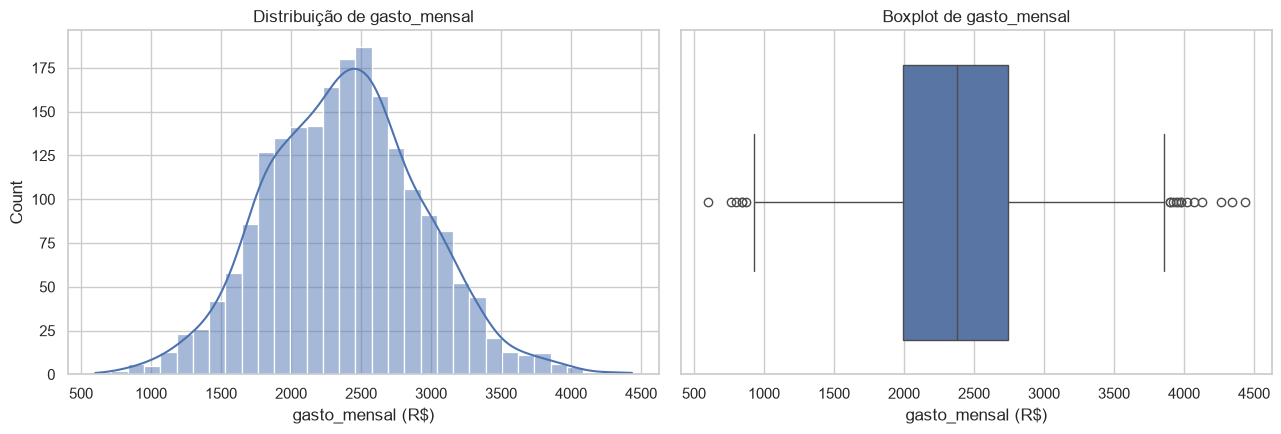

Assimetria (skew): 0.126
Curtose (excesso): 0.107


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
visualization.plot_target_distribution(df[target], axes[0], axes[1], label=target)
plt.tight_layout()
plt.show()

print(f"Assimetria (skew): {stats.skew(df[target]):.3f}")
print(f"Curtose (excesso): {stats.kurtosis(df[target]):.3f}")

O gráfico mostra uma distribuição praticamente simétrica, sem caudas longas nem concentração de valores extremos. Por isso, a variável não parece precisar de nenhuma transformação neste momento.

In [11]:
q1, q3 = df[target].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = df[(df[target] < lower) | (df[target] > upper)]
print(f"Limites IQR: [{lower:.1f}, {upper:.1f}]")
print(f"Outliers pela regra 1.5xIQR: {len(outliers)} ({len(outliers)/len(df):.1%} da base)")

Limites IQR: [871.9, 3860.9]
Outliers pela regra 1.5xIQR: 19 (0.9% da base)


A regra do IQR encontrou poucos valores extremos na target. Foram mantidos, já que podem representar comportamentos reais de clientes.

## 5. EDA univariada de todas as features

Além da distribuição da target, olhamos aqui a distribuição de cada uma das 9 features individualmente (histograma, boxplot e checagem de outliers), e não só a correlação agregada delas com a target.

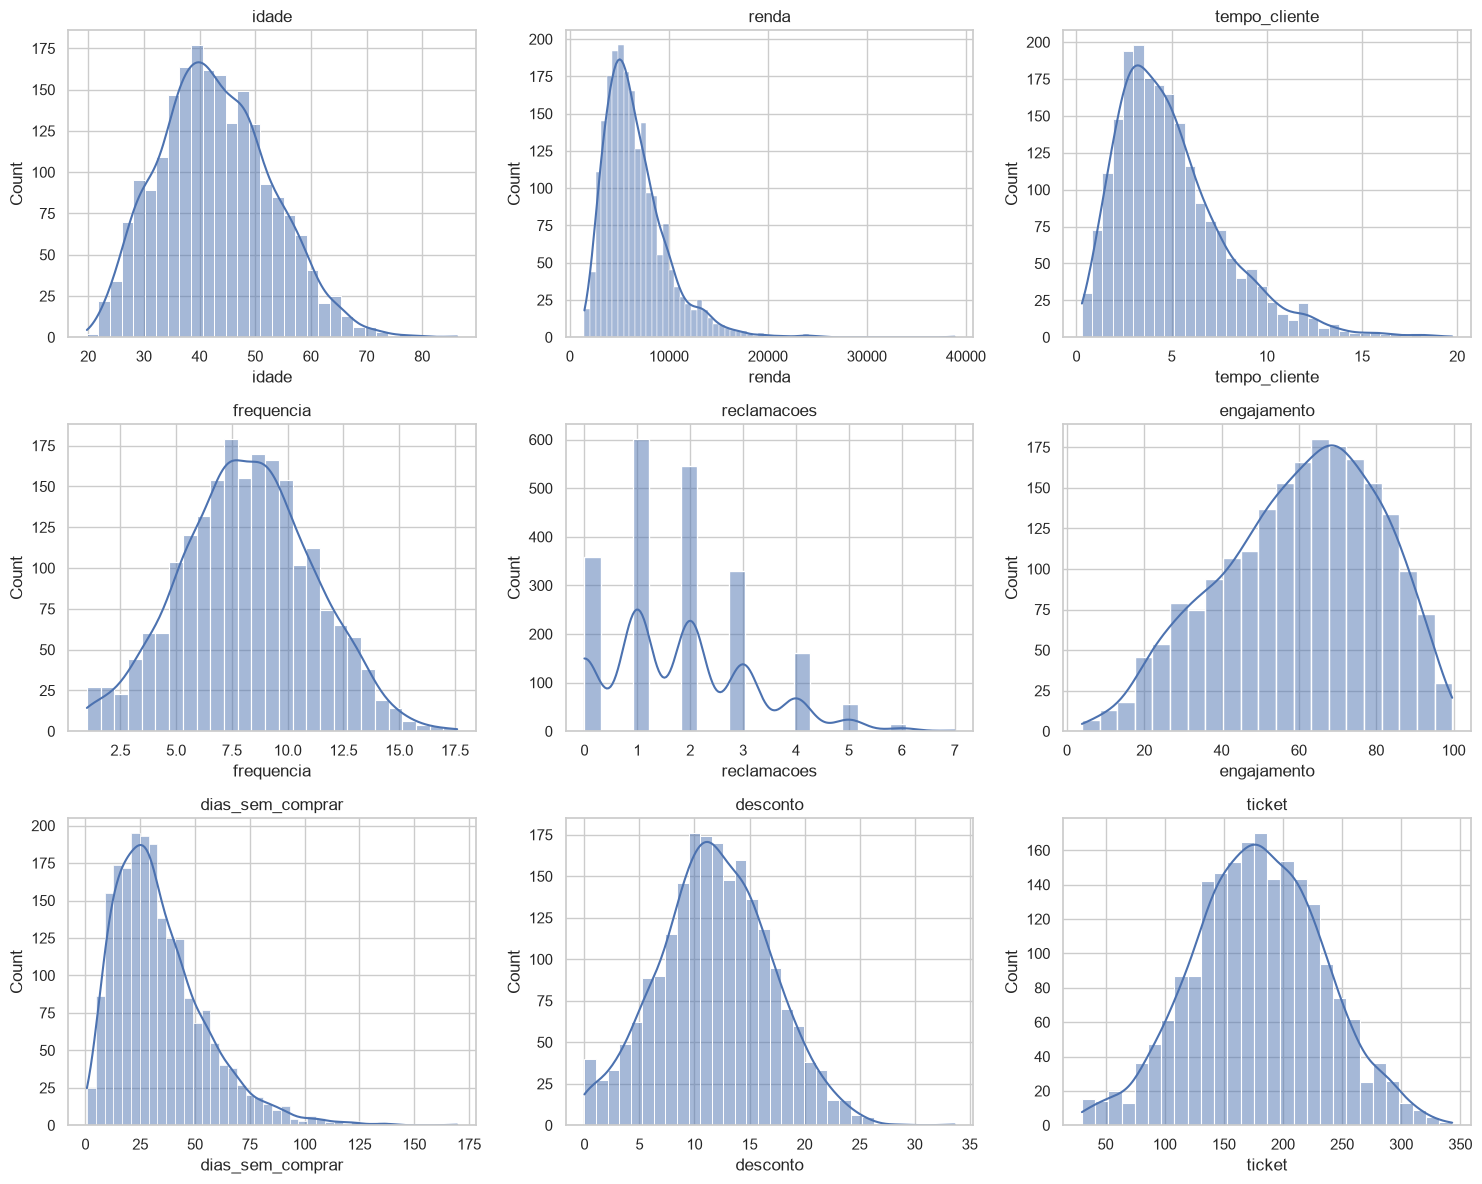

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.ravel(), features):
    sns.histplot(df[col], kde=True, ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [21]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import math

n_cols = 2
n_rows = math.ceil(len(features) / n_cols)

fig = make_subplots(
    rows=n_rows,
    cols=n_cols,
    subplot_titles=features
)

for i, col in enumerate(features):
    row = i // n_cols + 1
    col_pos = i % n_cols + 1

    fig.add_trace(
        go.Box(
            y=df[col],
            name=col,
            boxpoints="outliers"
        ),
        row=row,
        col=col_pos
    )

fig.update_layout(
    title="Distribuição e outliers das variáveis",
    height=300 * n_rows,
    showlegend=False
)

fig.show()

- renda: forte assimetria à direita, cauda longa até ~25k, um outlier isolado perto de 38k. Variável mais "problemática" em termos de outliers.
- dias_sem_comprar: também bem assimétrica, maioria até ~80, outliers chegando a 160+.
- tempo_cliente: assimétrica, outliers acima de ~12 até quase 20.
- idade: distribuição razoável, poucos outliers no topo (~80 anos).
- reclamacoes e desconto: outliers pontuais, mas discretos.
- frequencia, engajamento, ticket: bem comportadas, sem outliers relevantes, distribuição mais simétrica.


## 6. Correlações e colinearidade

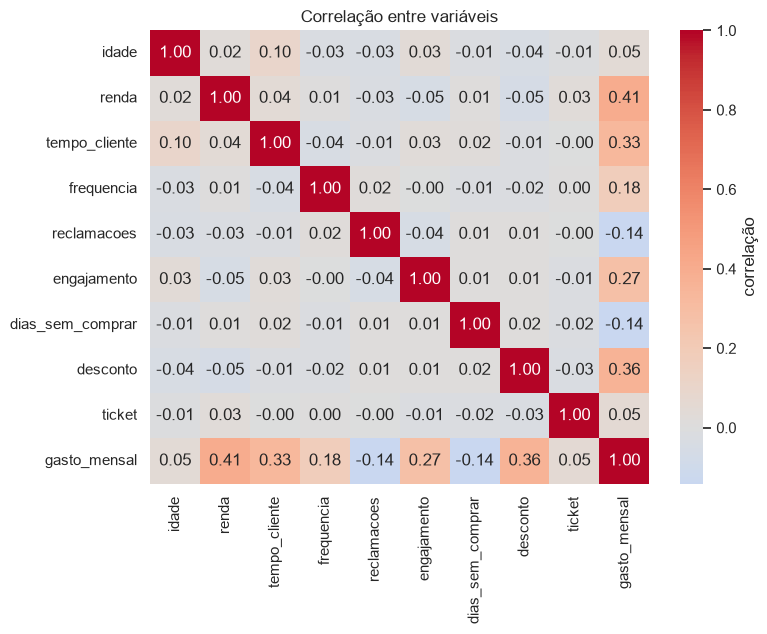

In [22]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, cbar_kws={"label": "correlação"})
ax.set_title("Correlação entre variáveis")
plt.tight_layout()
plt.show()

- renda (0,41), desconto (0,36), tempo_cliente (0,33), engajamento (0,27): mais correlacionadas com o gasto — batem com as features mais importantes do modelo.
- Sem multicolinearidade entre features (todas baixas entre si).

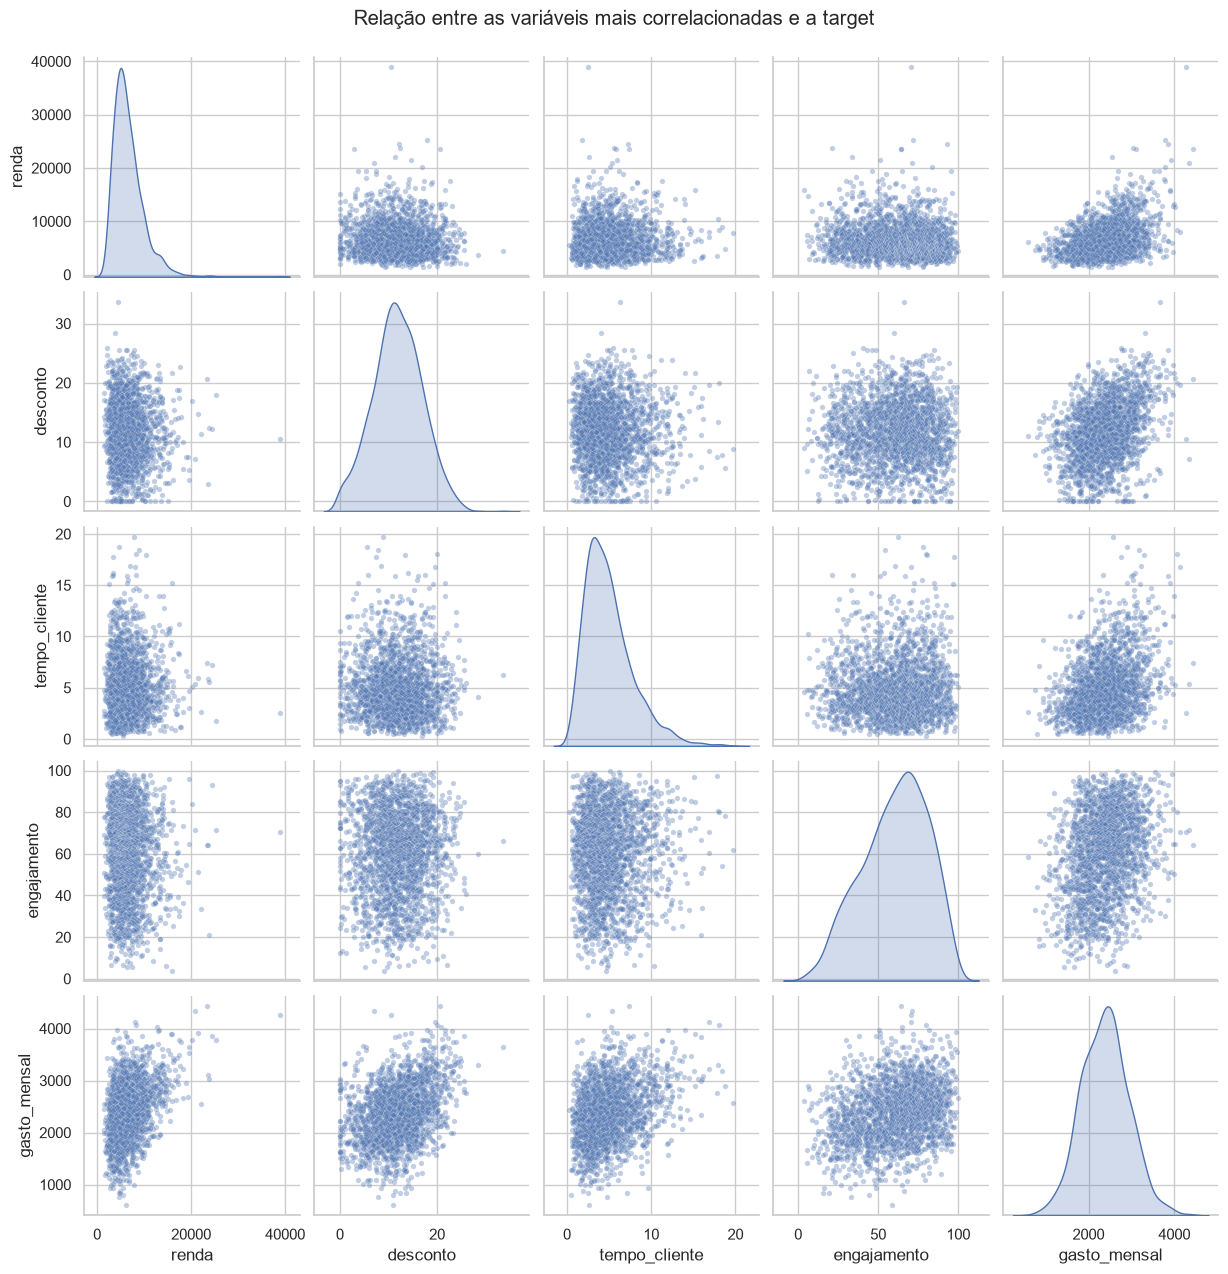

In [16]:
pair_cols = ["renda", "desconto", "tempo_cliente", "engajamento", target]
g = sns.pairplot(df[pair_cols], diag_kind="kde", plot_kws={"alpha": 0.35, "s": 15})
g.fig.suptitle("Relação entre as variáveis mais correlacionadas e a target", y=1.02)
plt.show()

## Saída desta etapa

In [17]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
df.to_csv(PROCESSED_DIR / "dataset_limpo.csv", index=False)
print("Salvo em:", PROCESSED_DIR / "dataset_limpo.csv")
print("Linhas removidas por idade implausível:", n_idade_invalida)
print("Linhas removidas por tempo_cliente inconsistente com a idade:", n_tempo_invalido)

Salvo em: c:\Users\MarianaCostadeMello\Downloads\Treinamento DS\Case 3\data\processed\dataset_limpo.csv
Linhas removidas por idade implausível: 39
Linhas removidas por tempo_cliente inconsistente com a idade: 89
